# 理想振幅因子研报复现

**原始研报：** 开源证券《振幅因子的隐藏结构——市场微观结构研究系列（7）》  
**研究区间：** 2019—2024年  
**数据来源：** BigQuant A股日频行情  
**基准参数：** N=20，λ=25%  
**调仓频率：** 月度

In [1]:
from bigmodule import M, I
import dai
import pandas as pd
import numpy as np

sql = """
SELECT
    date,
    instrument,
    high,
    low,
    close
FROM cn_stock_bar1d
WHERE date >= '2024-01-01'
  AND date <= '2024-03-31'
ORDER BY date, instrument
"""

data = dai.query(sql).df()

print(data.columns.tolist())
print(data.head())
print(data.shape)

['date', 'instrument', 'high', 'low', 'close']
        date instrument         high          low        close
0 2024-01-02  000001.SZ  1099.433777  1074.924107  1074.924107
1 2024-01-02  000002.SZ  1904.255626  1844.293378  1844.293378
2 2024-01-02  000004.SZ    66.809889    65.224983    65.590730
3 2024-01-02  000005.SZ    10.379715    10.009011    10.379715
4 2024-01-02  000006.SZ   182.802499   176.841548   177.636341
(310218, 5)


In [3]:
# 复制原始数据，避免修改 data
bars = data.copy()

bars["date"] = pd.to_datetime(bars["date"])
bars = bars.sort_values(["instrument", "date"])

# 每日振幅
bars["amplitude"] = bars["high"] / bars["low"] - 1

# 基础数据检查
bars = bars.replace([np.inf, -np.inf], np.nan)
bars = bars.dropna(
    subset=["instrument", "date", "close", "amplitude"]
)
bars = bars[
    (bars["close"] > 0) &
    (bars["high"] > 0) &
    (bars["low"] > 0)
]

print(bars[[
    "date",
    "instrument",
    "high",
    "low",
    "close",
    "amplitude"
]].head())

print("\n振幅统计：")
print(bars["amplitude"].describe())

            date instrument         high          low        close  amplitude
0     2024-01-02  000001.SZ  1099.433777  1074.924107  1074.924107   0.022801
5335  2024-01-03  000001.SZ  1076.091234  1067.921344  1073.756979   0.007650
10671 2024-01-04  000001.SZ  1072.589852  1059.751454  1063.252835   0.012115
16007 2024-01-05  000001.SZ  1101.768031  1058.584326  1081.926869   0.040794
21344 2024-01-08  000001.SZ  1085.428251  1063.252835  1067.921344   0.020856

振幅统计：
count    309892.000000
mean          0.051987
std           0.036976
min           0.000000
25%           0.027572
50%           0.040872
75%           0.063425
max           0.608696
Name: amplitude, dtype: float64


In [4]:
LOOKBACK = 20
CUT_RATIO = 0.25
CUT_DAYS = int(LOOKBACK * CUT_RATIO)  # 5天


def calculate_raw_factor(window):
    """
    计算一只股票在一个调仓日的 V_high 和 V_low。
    window 必须是截至调仓日最近20个有效交易日。
    """
    if len(window) < LOOKBACK:
        return pd.Series({
            "v_high": np.nan,
            "v_low": np.nan,
            "n_obs": len(window),
        })

    window = window.tail(LOOKBACK).sort_values(
        ["close", "date"]
    )

    low_price_days = window.head(CUT_DAYS)
    high_price_days = window.tail(CUT_DAYS)

    return pd.Series({
        "v_high": high_price_days["amplitude"].mean(),
        "v_low": low_price_days["amplitude"].mean(),
        "n_obs": len(window),
    })


def cross_sectional_process(factor):
    """
    分别对 V_high 和 V_low 做1%/99%缩尾及Z-score标准化。
    """
    factor = factor.copy()

    for column in ["v_high", "v_low"]:
        lower = factor[column].quantile(0.01)
        upper = factor[column].quantile(0.99)

        clipped = factor[column].clip(lower, upper)
        std = clipped.std(ddof=0)

        if std == 0 or pd.isna(std):
            factor[f"z_{column}"] = np.nan
        else:
            factor[f"z_{column}"] = (
                clipped - clipped.mean()
            ) / std

    factor["ideal_amplitude"] = (
        factor["z_v_high"] - factor["z_v_low"]
    )

    return factor

In [5]:
# 选择一个因子计算日
signal_date = pd.Timestamp("2024-03-29")

# 只能使用计算日及之前的数据，避免未来函数
history = bars[bars["date"] <= signal_date].copy()

# 对每只股票取截至计算日的历史数据并计算 V_high、V_low
factor_202403 = (
    history
    .groupby("instrument")
    .apply(calculate_raw_factor)
    .reset_index()
)

# 只保留具有完整20日观察数据的股票
factor_202403 = factor_202403[
    factor_202403["n_obs"] == LOOKBACK
].copy()

# 横截面标准化并构造理想振幅因子
factor_202403 = cross_sectional_process(factor_202403)

print("计算日期：", signal_date.date())
print("有效股票数量：", factor_202403["ideal_amplitude"].notna().sum())

display(
    factor_202403[
        [
            "instrument",
            "v_high",
            "v_low",
            "z_v_high",
            "z_v_low",
            "ideal_amplitude",
        ]
    ].head(10)
)

display(
    factor_202403[
        ["v_high", "v_low", "ideal_amplitude"]
    ].describe()
)

计算日期： 2024-03-29
有效股票数量： 5351


,instrument,v_high,v_low,z_v_high,z_v_low,ideal_amplitude
0,000001.SZ,0.017398,0.016911,-1.186321,-1.613133,0.426813
1,000002.SZ,0.040613,0.019771,-0.229377,-1.409659,1.180282
2,000004.SZ,0.084641,0.068918,1.585482,2.087571,-0.502089
3,000005.SZ,0.067241,0.060418,0.868218,1.482711,-0.614493
4,000006.SZ,0.023149,0.031185,-0.949283,-0.597456,-0.351827
5,000007.SZ,0.046590,0.045529,0.016984,0.423230,-0.406245
6,000008.SZ,0.075277,0.035110,1.199474,-0.318168,1.517642
7,000009.SZ,0.030441,0.024952,-0.648686,-1.040960,0.392275
8,000010.SZ,0.029011,0.046409,-0.707647,0.485842,-1.193489
9,000011.SZ,0.034564,0.019467,-0.478722,-1.431264,0.952542


,v_high,v_low,ideal_amplitude
count,5351.000000,5351.000000,5.351000e+03
mean,0.046332,0.039713,-3.107214e-16
std,0.024927,0.014755,9.613777e-01
min,0.009726,0.000000,-3.711288e+00
25%,0.028378,0.029263,-6.009780e-01
50%,0.039420,0.037861,-1.130269e-02
75%,0.057827,0.047951,4.792259e-01
max,0.196599,0.198103,4.484062e+00


In [6]:
sql = """
SELECT
    date,
    instrument,
    high,
    low,
    close
FROM cn_stock_bar1d
WHERE date >= '2023-12-01'
  AND date <= '2024-05-31'
ORDER BY date, instrument
"""

data = dai.query(sql).df()

data["date"] = pd.to_datetime(data["date"])

bars = data.copy()
bars["amplitude"] = bars["high"] / bars["low"] - 1

bars = (
    bars
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[
        "date", "instrument", "high",
        "low", "close", "amplitude"
    ])
)

bars = bars[
    (bars["high"] > 0) &
    (bars["low"] > 0) &
    (bars["close"] > 0)
].sort_values(["instrument", "date"])

print(bars["date"].min(), bars["date"].max())
print(bars.shape)

2023-12-01 00:00:00 2024-05-31 00:00:00
(635519, 6)


In [7]:
signal_date = pd.Timestamp("2024-03-29")

history = bars[bars["date"] <= signal_date]

factor_202403 = (
    history
    .groupby("instrument")
    .apply(calculate_raw_factor)
    .reset_index()
)

factor_202403 = factor_202403[
    factor_202403["n_obs"] == LOOKBACK
].copy()

factor_202403 = cross_sectional_process(factor_202403)

print("因子股票数：", len(factor_202403))

因子股票数： 5353


In [8]:
# 找到4月份最后一个实际交易日
april_data = bars[
    (bars["date"] >= "2024-04-01") &
    (bars["date"] <= "2024-04-30")
]

next_date = april_data["date"].max()

print("因子日期：", signal_date.date())
print("收益结束日期：", next_date.date())

# 3月末收盘价
start_price = (
    bars[bars["date"] == signal_date]
    [["instrument", "close"]]
    .rename(columns={"close": "start_close"})
)

# 4月末收盘价
end_price = (
    bars[bars["date"] == next_date]
    [["instrument", "close"]]
    .rename(columns={"close": "end_close"})
)

# 计算未来一个月收益
forward_return = start_price.merge(
    end_price,
    on="instrument",
    how="inner"
)

forward_return["forward_return"] = (
    forward_return["end_close"]
    / forward_return["start_close"]
    - 1
)

display(forward_return.head())
print(forward_return["forward_return"].describe())

因子日期： 2024-03-29
收益结束日期： 2024-04-30


,instrument,start_close,end_close,forward_return
0,000001.SZ,1227.817763,1259.330196,0.025665
1,000002.SZ,1635.334030,1346.425026,-0.176667
2,000004.SZ,61.161121,41.492029,-0.321595
3,000006.SZ,156.971711,153.792537,-0.020253
4,000007.SZ,37.027372,35.122160,-0.051454


count    5292.000000
mean       -0.017124
std         0.116070
min        -0.821782
25%        -0.079632
50%        -0.022371
75%         0.036461
max         3.617170
Name: forward_return, dtype: float64


In [9]:
evaluation = factor_202403.merge(
    forward_return[
        ["instrument", "forward_return"]
    ],
    on="instrument",
    how="inner"
)

evaluation = evaluation.dropna(
    subset=["ideal_amplitude", "forward_return"]
)

# Spearman相关系数，即RankIC
rank_ic = evaluation[
    ["ideal_amplitude", "forward_return"]
].corr(method="spearman").iloc[0, 1]

# 普通Pearson相关系数
ic = evaluation[
    ["ideal_amplitude", "forward_return"]
].corr(method="pearson").iloc[0, 1]

print("有效样本数：", len(evaluation))
print(f"IC：{ic:.4f}")
print(f"RankIC：{rank_ic:.4f}")

有效样本数： 5283
IC：0.0002
RankIC：0.0407


In [10]:
sql = """
SELECT
    date,
    instrument,
    high,
    low,
    close
FROM cn_stock_bar1d
WHERE date >= '2018-11-01'
  AND date <= '2024-12-31'
ORDER BY date, instrument
"""

data = dai.query(sql).df()

data["date"] = pd.to_datetime(data["date"])

bars = data.copy()
bars["amplitude"] = bars["high"] / bars["low"] - 1

bars = (
    bars
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[
        "date", "instrument", "high",
        "low", "close", "amplitude"
    ])
)

bars = bars[
    (bars["high"] > 0) &
    (bars["low"] > 0) &
    (bars["close"] > 0)
].sort_values(["instrument", "date"])

print("数据区间：", bars["date"].min(), "至", bars["date"].max())
print("数据行数：", len(bars))

数据区间： 2018-11-01 00:00:00 至 2024-12-31 00:00:00
数据行数： 6763759


In [11]:
trading_dates = (
    bars[["date"]]
    .drop_duplicates()
    .sort_values("date")
)

trading_dates["month"] = trading_dates["date"].dt.to_period("M")

month_ends = (
    trading_dates
    .groupby("month")["date"]
    .max()
    .sort_values()
    .tolist()
)

# 正式评价从2019年1月末开始
month_ends = [
    date for date in month_ends
    if pd.Timestamp("2019-01-01") <= date
]

print("月末数量：", len(month_ends))
print("前5个月末：", month_ends[:5])
print("后5个月末：", month_ends[-5:])

月末数量： 72
前5个月末： [Timestamp('2019-01-31 00:00:00'), Timestamp('2019-02-28 00:00:00'), Timestamp('2019-03-29 00:00:00'), Timestamp('2019-04-30 00:00:00'), Timestamp('2019-05-31 00:00:00')]
后5个月末： [Timestamp('2024-08-30 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-11-29 00:00:00'), Timestamp('2024-12-31 00:00:00')]


In [12]:
monthly_results = []
all_monthly_data = []

for i in range(len(month_ends) - 1):
    signal_date = month_ends[i]
    next_date = month_ends[i + 1]

    # 截至本月末的数据
    history = bars[bars["date"] <= signal_date]

    factor = (
        history
        .groupby("instrument")
        .apply(calculate_raw_factor)
        .reset_index()
    )

    factor = factor[
        factor["n_obs"] == LOOKBACK
    ].copy()

    factor = cross_sectional_process(factor)

    start_price = (
        bars[bars["date"] == signal_date]
        [["instrument", "close"]]
        .rename(columns={"close": "start_close"})
    )

    end_price = (
        bars[bars["date"] == next_date]
        [["instrument", "close"]]
        .rename(columns={"close": "end_close"})
    )

    forward_return = start_price.merge(
        end_price,
        on="instrument",
        how="inner"
    )

    forward_return["forward_return"] = (
        forward_return["end_close"]
        / forward_return["start_close"]
        - 1
    )

    evaluation = factor.merge(
        forward_return[
            ["instrument", "forward_return"]
        ],
        on="instrument",
        how="inner"
    ).dropna(
        subset=["ideal_amplitude", "forward_return"]
    )

    if len(evaluation) < 100:
        continue

    ic = evaluation[
        ["ideal_amplitude", "forward_return"]
    ].corr(method="pearson").iloc[0, 1]

    rank_ic = evaluation[
        ["ideal_amplitude", "forward_return"]
    ].corr(method="spearman").iloc[0, 1]

    evaluation["signal_date"] = signal_date
    evaluation["next_date"] = next_date
    all_monthly_data.append(evaluation)

    monthly_results.append({
        "signal_date": signal_date,
        "next_date": next_date,
        "sample_count": len(evaluation),
        "ic": ic,
        "rank_ic": rank_ic,
    })

    print(
        signal_date.date(),
        "→",
        next_date.date(),
        f"RankIC={rank_ic:.4f}",
        f"N={len(evaluation)}"
    )

2019-01-31 → 2019-02-28 RankIC=-0.2240 N=3540
2019-02-28 → 2019-03-29 RankIC=-0.0960 N=3534
2019-03-29 → 2019-04-30 RankIC=-0.0606 N=3507
2019-04-30 → 2019-05-31 RankIC=-0.1258 N=3534
2019-05-31 → 2019-06-28 RankIC=-0.0330 N=3578
2019-06-28 → 2019-07-31 RankIC=-0.0401 N=3593
2019-07-31 → 2019-08-30 RankIC=-0.0921 N=3602
2019-08-30 → 2019-09-30 RankIC=-0.1625 N=3640
2019-09-30 → 2019-10-31 RankIC=-0.0485 N=3647
2019-10-31 → 2019-11-29 RankIC=-0.0213 N=3652
2019-11-29 → 2019-12-31 RankIC=-0.0205 N=3676
2019-12-31 → 2020-01-23 RankIC=-0.1073 N=3717
2020-01-23 → 2020-02-28 RankIC=0.0583 N=3738
2020-02-28 → 2020-03-31 RankIC=-0.1105 N=3753
2020-03-31 → 2020-04-30 RankIC=-0.1656 N=3729
2020-04-30 → 2020-05-29 RankIC=-0.0541 N=3733
2020-05-29 → 2020-06-30 RankIC=-0.1840 N=3770
2020-06-30 → 2020-07-31 RankIC=-0.0089 N=3795
2020-07-31 → 2020-08-31 RankIC=-0.1234 N=3836
2020-08-31 → 2020-09-30 RankIC=0.0589 N=3883
2020-09-30 → 2020-10-30 RankIC=-0.0085 N=3952
2020-10-30 → 2020-11-30 RankIC=0.020

In [13]:
ic_summary = pd.DataFrame(monthly_results)

rank_ic_mean = ic_summary["rank_ic"].mean()
rank_ic_std = ic_summary["rank_ic"].std(ddof=1)

rank_icir = (
    rank_ic_mean / rank_ic_std
    if rank_ic_std != 0
    else np.nan
)

negative_win_rate = (
    ic_summary["rank_ic"] < 0
).mean()

print("月份数量：", len(ic_summary))
print(f"平均IC：{ic_summary['ic'].mean():.4f}")
print(f"平均RankIC：{rank_ic_mean:.4f}")
print(f"RankIC标准差：{rank_ic_std:.4f}")
print(f"月度ICIR：{rank_icir:.4f}")
print(f"负向月份占比：{negative_win_rate:.2%}")

display(ic_summary.head())

月份数量： 71
平均IC：-0.0364
平均RankIC：-0.0517
RankIC标准差：0.0827
月度ICIR：-0.6243
负向月份占比：76.06%


,signal_date,next_date,sample_count,ic,rank_ic
0,2019-01-31,2019-02-28,3540,-0.140907,-0.224047
1,2019-02-28,2019-03-29,3534,-0.046321,-0.096037
2,2019-03-29,2019-04-30,3507,-0.053796,-0.060647
3,2019-04-30,2019-05-31,3534,-0.122221,-0.125841
4,2019-05-31,2019-06-28,3578,-0.042094,-0.032984


In [14]:
# 合并所有月份的股票因子与未来收益
panel = pd.concat(
    all_monthly_data,
    ignore_index=True
)

print("总样本数：", len(panel))
print("月份数量：", panel["signal_date"].nunique())

display(
    panel[
        [
            "signal_date",
            "instrument",
            "ideal_amplitude",
            "forward_return",
        ]
    ].head()
)

总样本数： 319649
月份数量： 71


,signal_date,instrument,ideal_amplitude,forward_return
0,2019-01-31,000001.SZ,-0.198173,0.113514
1,2019-01-31,000002.SZ,0.832702,0.008649
2,2019-01-31,000004.SZ,-1.284669,0.296667
3,2019-01-31,000005.SZ,2.152763,0.215548
4,2019-01-31,000006.SZ,0.228912,0.186770


In [15]:
def assign_groups(month_data, group_count=5):
    """
    根据理想振幅因子从低到高分成5组。

    Group 1：因子值最低，理论上未来收益最高
    Group 5：因子值最高，理论上未来收益最低
    """
    month_data = month_data.copy()

    # 先排序并生成唯一排名，避免分位数边界重复
    factor_rank = month_data[
        "ideal_amplitude"
    ].rank(method="first")

    month_data["group"] = pd.qcut(
        factor_rank,
        q=group_count,
        labels=range(1, group_count + 1)
    ).astype(int)

    return month_data


panel_grouped = (
    panel
    .groupby("signal_date", group_keys=False)
    .apply(assign_groups)
)

display(
    panel_grouped[
        [
            "signal_date",
            "instrument",
            "ideal_amplitude",
            "group",
            "forward_return",
        ]
    ].head(10)
)

,signal_date,instrument,ideal_amplitude,group,forward_return
0,2019-01-31,000001.SZ,-0.198173,3,0.113514
1,2019-01-31,000002.SZ,0.832702,5,0.008649
2,2019-01-31,000004.SZ,-1.284669,1,0.296667
3,2019-01-31,000005.SZ,2.152763,5,0.215548
4,2019-01-31,000006.SZ,0.228912,4,0.186770
5,2019-01-31,000007.SZ,-1.502742,1,0.431250
6,2019-01-31,000008.SZ,0.352233,4,0.282967
7,2019-01-31,000009.SZ,-0.272756,2,0.267813
8,2019-01-31,000010.SZ,-0.823782,2,0.199324
9,2019-01-31,000011.SZ,-0.560542,2,0.197790


In [16]:
monthly_group_returns = (
    panel_grouped
    .groupby(["signal_date", "group"])["forward_return"]
    .mean()
    .unstack("group")
    .sort_index()
)

monthly_group_returns.columns = [
    f"Group_{column}"
    for column in monthly_group_returns.columns
]

# 因子为负向：低因子组减高因子组
monthly_group_returns["Long_Short"] = (
    monthly_group_returns["Group_1"]
    - monthly_group_returns["Group_5"]
)

display(monthly_group_returns.head())

,Group_1,Group_2,Group_3,Group_4,Group_5,Long_Short
signal_date,,,,,,
2019-01-31,0.266021,0.229269,0.214351,0.193895,0.218710,0.047311
2019-02-28,0.113731,0.113568,0.099039,0.094443,0.098075,0.015657
2019-03-29,-0.033508,-0.035743,-0.034353,-0.037733,-0.051496,0.017988
2019-04-30,-0.025590,-0.042103,-0.041545,-0.059480,-0.063564,0.037974
2019-05-31,0.008783,0.007948,0.008863,0.006124,-0.003937,0.012720


In [17]:
group_summary = pd.DataFrame({
    "平均月收益": monthly_group_returns.mean(),
    "年化收益_简单": monthly_group_returns.mean() * 12,
    "年化波动": monthly_group_returns.std(ddof=1) * np.sqrt(12),
})

group_summary["年化收益风险比"] = (
    group_summary["年化收益_简单"]
    / group_summary["年化波动"]
)

display(
    group_summary.style.format({
        "平均月收益": "{:.2%}",
        "年化收益_简单": "{:.2%}",
        "年化波动": "{:.2%}",
        "年化收益风险比": "{:.2f}",
    })
)

,平均月收益,年化收益_简单,年化波动,年化收益风险比
Group_1,1.50%,18.01%,25.96%,0.69
Group_2,1.61%,19.37%,24.25%,0.80
Group_3,1.28%,15.37%,22.67%,0.68
Group_4,1.09%,13.09%,22.58%,0.58
Group_5,0.45%,5.35%,25.46%,0.21
Long_Short,1.06%,12.67%,9.95%,1.27


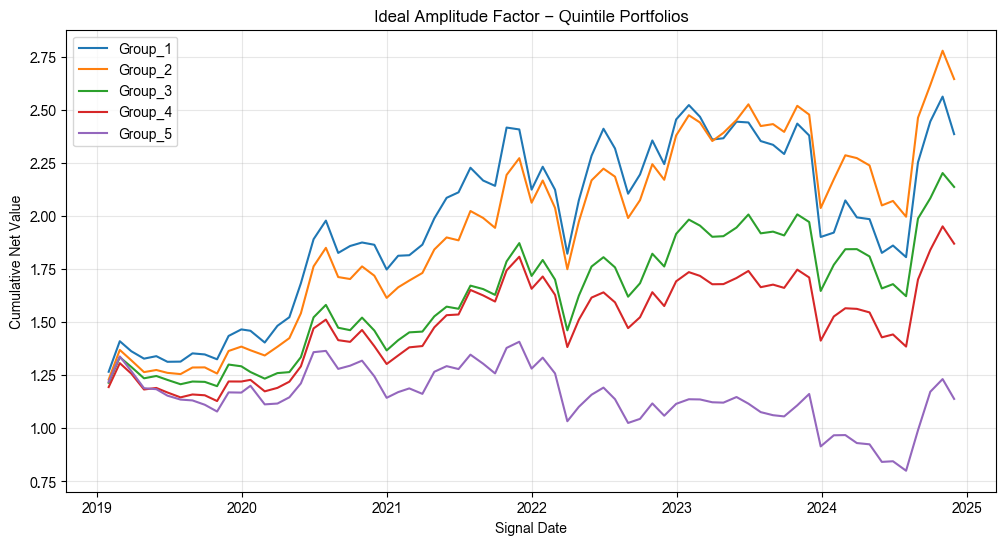

In [18]:
import matplotlib.pyplot as plt

net_value = (
    1 + monthly_group_returns
).cumprod()

plt.figure(figsize=(12, 6))

for column in [
    "Group_1",
    "Group_2",
    "Group_3",
    "Group_4",
    "Group_5",
]:
    plt.plot(
        net_value.index,
        net_value[column],
        label=column
    )

plt.title("Ideal Amplitude Factor - Quintile Portfolios")
plt.xlabel("Signal Date")
plt.ylabel("Cumulative Net Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

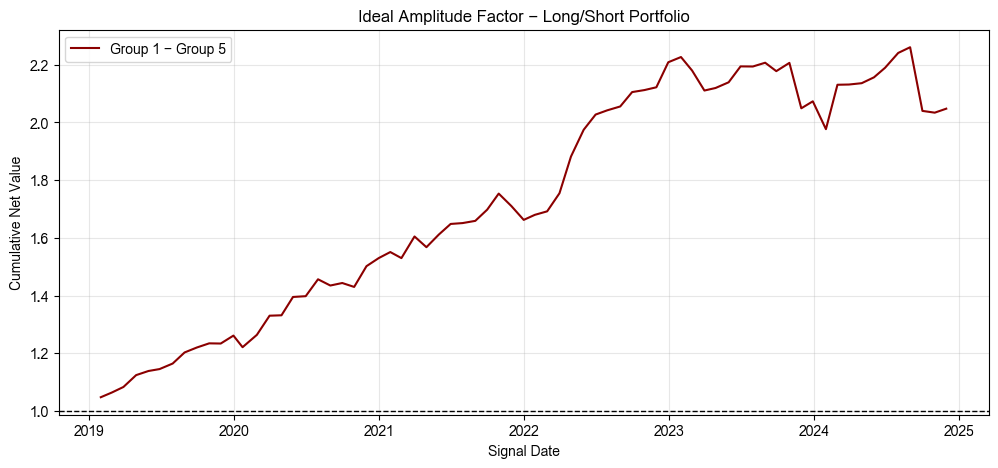

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    net_value.index,
    net_value["Long_Short"],
    label="Group 1 - Group 5",
    color="darkred"
)

plt.axhline(
    y=1,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Ideal Amplitude Factor - Long/Short Portfolio")
plt.xlabel("Signal Date")
plt.ylabel("Cumulative Net Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
def calculate_performance(monthly_returns):
    monthly_returns = monthly_returns.dropna()

    total_months = len(monthly_returns)
    total_return = (1 + monthly_returns).prod() - 1

    annual_return = (
        (1 + total_return) ** (12 / total_months) - 1
    )

    annual_volatility = (
        monthly_returns.std(ddof=1) * np.sqrt(12)
    )

    sharpe = (
        annual_return / annual_volatility
        if annual_volatility != 0
        else np.nan
    )

    net_value = (1 + monthly_returns).cumprod()
    running_max = net_value.cummax()
    drawdown = net_value / running_max - 1
    max_drawdown = drawdown.min()

    monthly_win_rate = (monthly_returns > 0).mean()

    return pd.Series({
        "月份数": total_months,
        "累计收益": total_return,
        "年化收益": annual_return,
        "年化波动": annual_volatility,
        "收益风险比": sharpe,
        "最大回撤": max_drawdown,
        "月度胜率": monthly_win_rate,
    })


performance_summary = pd.DataFrame({
    column: calculate_performance(
        monthly_group_returns[column]
    )
    for column in monthly_group_returns.columns
}).T

display(
    performance_summary.style.format({
        "月份数": "{:.0f}",
        "累计收益": "{:.2%}",
        "年化收益": "{:.2%}",
        "年化波动": "{:.2%}",
        "收益风险比": "{:.2f}",
        "最大回撤": "{:.2%}",
        "月度胜率": "{:.2%}",
    })
)

,月份数,累计收益,年化收益,年化波动,收益风险比,最大回撤,月度胜率
Group_1,71,138.57%,15.83%,25.96%,0.61,-28.40%,54.93%
Group_2,71,164.51%,17.87%,24.25%,0.74,-23.03%,56.34%
Group_3,71,113.69%,13.69%,22.67%,0.60,-21.95%,54.93%
Group_4,71,86.96%,11.16%,22.58%,0.49,-23.54%,56.34%
Group_5,71,13.82%,2.21%,25.46%,0.09,-43.17%,49.30%
Long_Short,71,104.79%,12.88%,9.95%,1.29,-11.23%,77.46%


In [21]:
group_columns = [
    "Group_1",
    "Group_2",
    "Group_3",
    "Group_4",
    "Group_5",
]

average_group_returns = (
    monthly_group_returns[group_columns]
    .mean()
)

display(
    average_group_returns
    .rename("平均月收益")
    .to_frame()
    .style.format("{:.2%}")
)

# 相邻分组中，前一组收益高于后一组的比例
monotonic_pairs = sum(
    average_group_returns.iloc[i]
    > average_group_returns.iloc[i + 1]
    for i in range(4)
)

print(
    f"满足递减关系的相邻组数：{monotonic_pairs}/4"
)

,平均月收益
Group_1,1.50%
Group_2,1.61%
Group_3,1.28%
Group_4,1.09%
Group_5,0.45%


满足递减关系的相邻组数：3/4


## Baseline Reproduction Result

### Conclusion

The main conclusion of the research report is basically reproduced.

From January 2019 to December 2024, the ideal amplitude factor shows
a persistent negative relationship with subsequent monthly stock returns.

### Main Results

| Metric | Report | Reproduction |
|---|---:|---:|
| IC Mean | -0.067 | -0.0364 |
| RankIC Mean | — | -0.0517 |
| Annualized RankICIR | — | -2.16 |
| Negative Month Ratio | 84.2% | 76.06% |
| Long-Short Annual Return | 23.3% | 12.88% |
| Long-Short Volatility | — | 9.95% |
| Long-Short Max Drawdown | — | -11.23% |
| Long-Short Monthly Win Rate | — | 77.46% |

### Quintile Result

The average monthly returns are:

| Portfolio | Average Monthly Return |
|---|---:|
| Group 1 | 1.50% |
| Group 2 | 1.61% |
| Group 3 | 1.28% |
| Group 4 | 1.09% |
| Group 5 | 0.45% |
| Group 1 - Group 5 | 1.05% |

Three out of four adjacent group relationships are monotonically decreasing.
Group 2 outperforms Group 1, so strict monotonicity is not achieved.

### Current Limitations

- No ST exclusion
- No newly listed stock exclusion
- No suspension and limit-up/limit-down trading restrictions
- No industry or market-cap neutralization
- No transaction costs
- Different test period from the original report
- Equal-weighted portfolios

In [22]:
import os

os.makedirs("outputs", exist_ok=True)

# 月度IC结果
ic_summary.to_csv(
    "outputs/monthly_ic.csv",
    index=False,
    encoding="utf-8-sig"
)

# 月度分组收益
monthly_group_returns.to_csv(
    "outputs/monthly_group_returns.csv",
    encoding="utf-8-sig"
)

# 绩效汇总
performance_summary.to_csv(
    "outputs/performance_summary.csv",
    encoding="utf-8-sig"
)

# 股票层面的因子和未来收益
panel_grouped[
    [
        "signal_date",
        "next_date",
        "instrument",
        "v_high",
        "v_low",
        "ideal_amplitude",
        "group",
        "forward_return",
    ]
].to_csv(
    "outputs/factor_evaluation_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("结果已保存：")
for filename in os.listdir("outputs"):
    print("-", filename)

结果已保存：
- factor_evaluation_panel.csv
- lookback_robustness.csv
- monthly_ic.csv
- monthly_group_returns.csv
- performance_summary.csv


In [23]:
def calculate_raw_factor_by_parameter(
    window,
    lookback,
    cut_ratio=0.25
):
    """
    按照指定回看窗口和价格切割比例，
    计算一只股票的 V_high 和 V_low。
    """

    if len(window) < lookback:
        return pd.Series({
            "v_high": np.nan,
            "v_low": np.nan,
            "n_obs": len(window),
        })

    cut_days = max(
        1,
        int(lookback * cut_ratio)
    )

    # 先取距离因子日最近的 lookback 个交易日，
    # 再按照收盘价从低到高排列
    window = (
        window
        .sort_values("date")
        .tail(lookback)
        .sort_values(["close", "date"])
    )

    low_price_days = window.head(cut_days)
    high_price_days = window.tail(cut_days)

    return pd.Series({
        "v_high": high_price_days["amplitude"].mean(),
        "v_low": low_price_days["amplitude"].mean(),
        "n_obs": len(window),
    })


def evaluate_lookback(
    bars,
    month_ends,
    lookback,
    cut_ratio=0.25
):
    """
    评价指定回看窗口下的因子表现。

    返回：
    - 平均 RankIC
    - 年化 ICIR
    - RankIC 为负的月份比例
    - 多空组合年化收益
    - 多空组合月度胜率
    """

    monthly_records = []

    for i in range(len(month_ends) - 1):
        signal_date = month_ends[i]
        next_date = month_ends[i + 1]

        # 只能使用信号日期及之前的数据
        history = bars.loc[
            bars["date"] <= signal_date
        ].copy()

        # 计算每只股票的 V_high 和 V_low
        factor = (
            history
            .groupby(
                "instrument",
                group_keys=False
            )
            .apply(
                calculate_raw_factor_by_parameter,
                lookback=lookback,
                cut_ratio=cut_ratio,
            )
            .reset_index()
        )

        # 只保留具有完整回看窗口的股票
        factor = factor.loc[
            factor["n_obs"] == lookback
        ].copy()

        if factor.empty:
            continue

        # 横截面缩尾、标准化并计算理想振幅
        factor = cross_sectional_process(factor)

        # 信号日收盘价
        start_price = (
            bars.loc[
                bars["date"] == signal_date,
                ["instrument", "close"]
            ]
            .drop_duplicates(
                subset=["instrument"]
            )
            .rename(columns={
                "close": "start_close"
            })
        )

        # 下一月末收盘价
        end_price = (
            bars.loc[
                bars["date"] == next_date,
                ["instrument", "close"]
            ]
            .drop_duplicates(
                subset=["instrument"]
            )
            .rename(columns={
                "close": "end_close"
            })
        )

        # 合并因子和价格
        evaluation = (
            factor
            .merge(
                start_price,
                on="instrument",
                how="inner"
            )
            .merge(
                end_price,
                on="instrument",
                how="inner"
            )
        )

        # 计算下一期收益
        evaluation["forward_return"] = (
            evaluation["end_close"]
            / evaluation["start_close"]
            - 1
        )

        evaluation = (
            evaluation
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=[
                "ideal_amplitude",
                "forward_return",
            ])
        )

        # 样本过少时跳过
        if len(evaluation) < 100:
            continue

        # RankIC：因子值与未来收益的 Spearman 相关系数
        rank_ic = (
            evaluation[
                ["ideal_amplitude", "forward_return"]
            ]
            .corr(method="spearman")
            .iloc[0, 1]
        )

        # 根据理想振幅从低到高分成五组
        evaluation["factor_rank"] = (
            evaluation["ideal_amplitude"]
            .rank(method="first")
        )

        evaluation["group"] = pd.qcut(
            evaluation["factor_rank"],
            q=5,
            labels=[1, 2, 3, 4, 5]
        ).astype(int)

        group_returns = (
            evaluation
            .groupby(
                "group",
                observed=True
            )["forward_return"]
            .mean()
        )

        # 必须同时包含第一组和第五组
        if (
            1 not in group_returns.index
            or 5 not in group_returns.index
        ):
            continue

        # 负向因子：做多低因子组，做空高因子组
        long_short_return = (
            group_returns.loc[1]
            - group_returns.loc[5]
        )

        monthly_records.append({
            "signal_date": signal_date,
            "next_date": next_date,
            "rank_ic": rank_ic,
            "long_short": long_short_return,
            "sample_count": len(evaluation),
        })

    monthly_detail = pd.DataFrame(
        monthly_records
    )

    if monthly_detail.empty:
        return {
            "lookback": lookback,
            "cut_ratio": cut_ratio,
            "months": 0,
            "mean_rank_ic": np.nan,
            "annualized_icir": np.nan,
            "negative_month_ratio": np.nan,
            "long_short_annual_return": np.nan,
            "long_short_month_win_rate": np.nan,
        }

    months = len(monthly_detail)

    rank_ic_mean = (
        monthly_detail["rank_ic"].mean()
    )

    rank_ic_std = (
        monthly_detail["rank_ic"].std(ddof=1)
    )

    if (
        pd.isna(rank_ic_std)
        or rank_ic_std == 0
    ):
        annualized_icir = np.nan
    else:
        annualized_icir = (
            rank_ic_mean
            / rank_ic_std
            * np.sqrt(12)
        )

    cumulative_growth = (
        1 + monthly_detail["long_short"]
    ).prod()

    if (
        cumulative_growth > 0
        and months > 0
    ):
        long_short_annual_return = (
            cumulative_growth ** (12 / months)
            - 1
        )
    else:
        long_short_annual_return = np.nan

    return {
        "lookback": lookback,
        "cut_ratio": cut_ratio,
        "months": months,
        "mean_rank_ic": rank_ic_mean,
        "annualized_icir": annualized_icir,
        "negative_month_ratio": (
            monthly_detail["rank_ic"] < 0
        ).mean(),
        "long_short_annual_return": (
            long_short_annual_return
        ),
        "long_short_month_win_rate": (
            monthly_detail["long_short"] > 0
        ).mean(),
    }

In [24]:
robustness_results = []

for lookback in [10, 20, 40, 60]:
    print(f"正在测试 N={lookback} ...")

    result = evaluate_lookback(
        bars=bars,
        month_ends=month_ends,
        lookback=lookback,
        cut_ratio=0.25,
    )

    robustness_results.append(result)

    print(
        f"N={lookback} 完成："
        f"RankIC={result['mean_rank_ic']:.4f}，"
        f"多空年化={result['long_short_annual_return']:.2%}"
    )

robustness_summary = pd.DataFrame(
    robustness_results
)

display(
    robustness_summary.style.format({
        "cut_ratio": "{:.0%}",
        "mean_rank_ic": "{:.4f}",
        "annualized_icir": "{:.2f}",
        "negative_month_ratio": "{:.2%}",
        "long_short_annual_return": "{:.2%}",
        "long_short_month_win_rate": "{:.2%}",
    })
)

正在测试 N=10 ...


In [ ]:
robustness_summary.to_csv(
    "outputs/lookback_robustness.csv",
    index=False,
    encoding="utf-8-sig"
)

print("已保存 outputs/lookback_robustness.csv")

已保存 outputs/lookback_robustness.csv


## Final Conclusion

本项目基本复现了开源证券《振幅因子的隐藏结构》中的理想振幅因子。

在2019—2024年全A股样本中，基准参数 `N=20、λ=25%` 下：

- 平均 RankIC：-0.0517
- 年化 ICIR：-2.16
- RankIC 负向月份占比：76.06%
- 多空组合年化收益：12.88%
- 多空组合最大回撤：-11.23%
- 多空月度胜率：77.46%

五分组收益整体呈下降趋势，其中3/4组相邻关系满足单调递减。
Group 2收益高于Group 1，因此未达到严格单调。

在 `N=10、20、40、60` 的稳健性测试中：

| N | RankIC | 年化ICIR | 多空年化收益 |
|---:|---:|---:|---:|
| 10 | -0.0414 | -1.86 | 11.22% |
| 20 | -0.0517 | -2.16 | 12.88% |
| 40 | -0.0461 | -1.71 | 10.20% |
| 60 | -0.0457 | -1.62 | 9.53% |

所有窗口均表现出负向选股能力，多空收益均为正，说明因子并非只在单一参数下有效。

总体而言，复现结果与研报核心结论一致，但多空收益强度低于原研报。差异可能来自测试区间、股票池过滤、数据源、复权口径及交易规则不同。

当前测试未考虑ST、新股、停牌、交易成本及行业市值中性化，因此结果属于研究层面的基础复现，不代表实际可交易收益。